# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [1]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.6.1 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 yellowbrick==1.5 -q --user

In [2]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2 --no-warn-script-location

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
# Importing libraries
# Libraries for data handling
import pandas as pd
import numpy as np
# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing and clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
# Hierarchical clustering and cophenetic correlation
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
# K selection visualizers
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import time



## Data Overview

- Observations
- Sanity checks

In [4]:
# Loading dataset 
Trade_df = pd.read_csv('stock_data.csv')
Trade_df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [5]:
Trade_df.shape

(340, 15)

* The datasets consists of 340 rows and 15 columns.

In [6]:
# Checks datatypes
Trade_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

#### Observation
The dataset consists of 4 categorical columns and 11 numerical columns.

- Four columns are of object type: Ticker Symbol, Security, GICS Sector, and GICS Sub Industry.
- Seven columns are of float64 type: Current Price, Price Change, Volatility, Earnings Per Share, Estimated Shares Outstanding, P/E Ratio, and P/B Ratio.
- Four columns are of int64 type: ROE, Cash Ratio, Net Cash Flow, and Net Income.

In [7]:
# Statistical Summary 
Trade_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.0,8.086234e+01,9.805509e+01,4.500000e+00,3.855500e+01,5.970500e+01,9.288000e+01,1.274950e+03
Price Change,340.0,4.078194e+00,1.200634e+01,-4.712969e+01,-9.394838e-01,4.819505e+00,1.069549e+01,5.505168e+01
Volatility,340.0,1.525976e+00,5.917984e-01,7.331632e-01,1.134878e+00,1.385593e+00,1.695549e+00,4.580042e+00
ROE,340.0,3.959706e+01,9.654754e+01,1.000000e+00,9.750000e+00,1.500000e+01,2.700000e+01,9.170000e+02
Cash Ratio,340.0,7.002353e+01,9.042133e+01,0.000000e+00,1.800000e+01,4.700000e+01,9.900000e+01,9.580000e+02
Net Cash Flow,340.0,5.553762e+07,1.946365e+09,-1.120800e+10,-1.939065e+08,2.098000e+06,1.698108e+08,2.076400e+10
Net Income,340.0,1.494385e+09,3.940150e+09,-2.352800e+10,3.523012e+08,7.073360e+08,1.899000e+09,2.444200e+10
Earnings Per Share,340.0,2.776662e+00,6.587779e+00,-6.120000e+01,1.557500e+00,2.895000e+00,4.620000e+00,5.009000e+01
Estimated Shares Outstanding,340.0,5.770283e+08,8.458496e+08,2.767216e+07,1.588482e+08,3.096751e+08,5.731175e+08,6.159292e+09
P/E Ratio,340.0,3.261256e+01,4.434873e+01,2.935451e+00,1.504465e+01,2.081988e+01,3.176476e+01,5.280391e+02


#### Observation

- Current Price has a mean of 80.86 and a median of 59.71, with values ranging from 4.50 to 1,274.95, indicating considerable variation in stock prices.
- Price Change has a mean of 4.08%, with values ranging from -47.13% to 55.05%, showing that some stocks experienced both significant decreases and increases.
- Volatility has a mean of 1.53 and ranges from 0.73 to 4.58, indicating differences in the level of price fluctuations among the stocks.
- ROE and Cash Ratio show substantial variation, with maximum values of 917 and 958 respectively, suggesting the presence of potential outliers.
- Net Cash Flow and Net Income have large standard deviations compared to their means, indicating considerable variation in financial performance across companies.
- P/E Ratio has a mean of 32.61 and a median of 20.82, while its maximum value of 528.04 suggests the presence of potential outliers.
- P/B Ratio has a mean of -1.72 and ranges from -76.12 to 129.06, indicating substantial variation among companies.

In [8]:
# Checking Missing values
Trade_df.isnull().sum()

Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64

* There  no missing values in the dataset.

In [9]:
# Checking for duplicates 
Trade_df.duplicated().sum()

0

* There are no duplicate records in the dataset.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

### Univariant Analysis

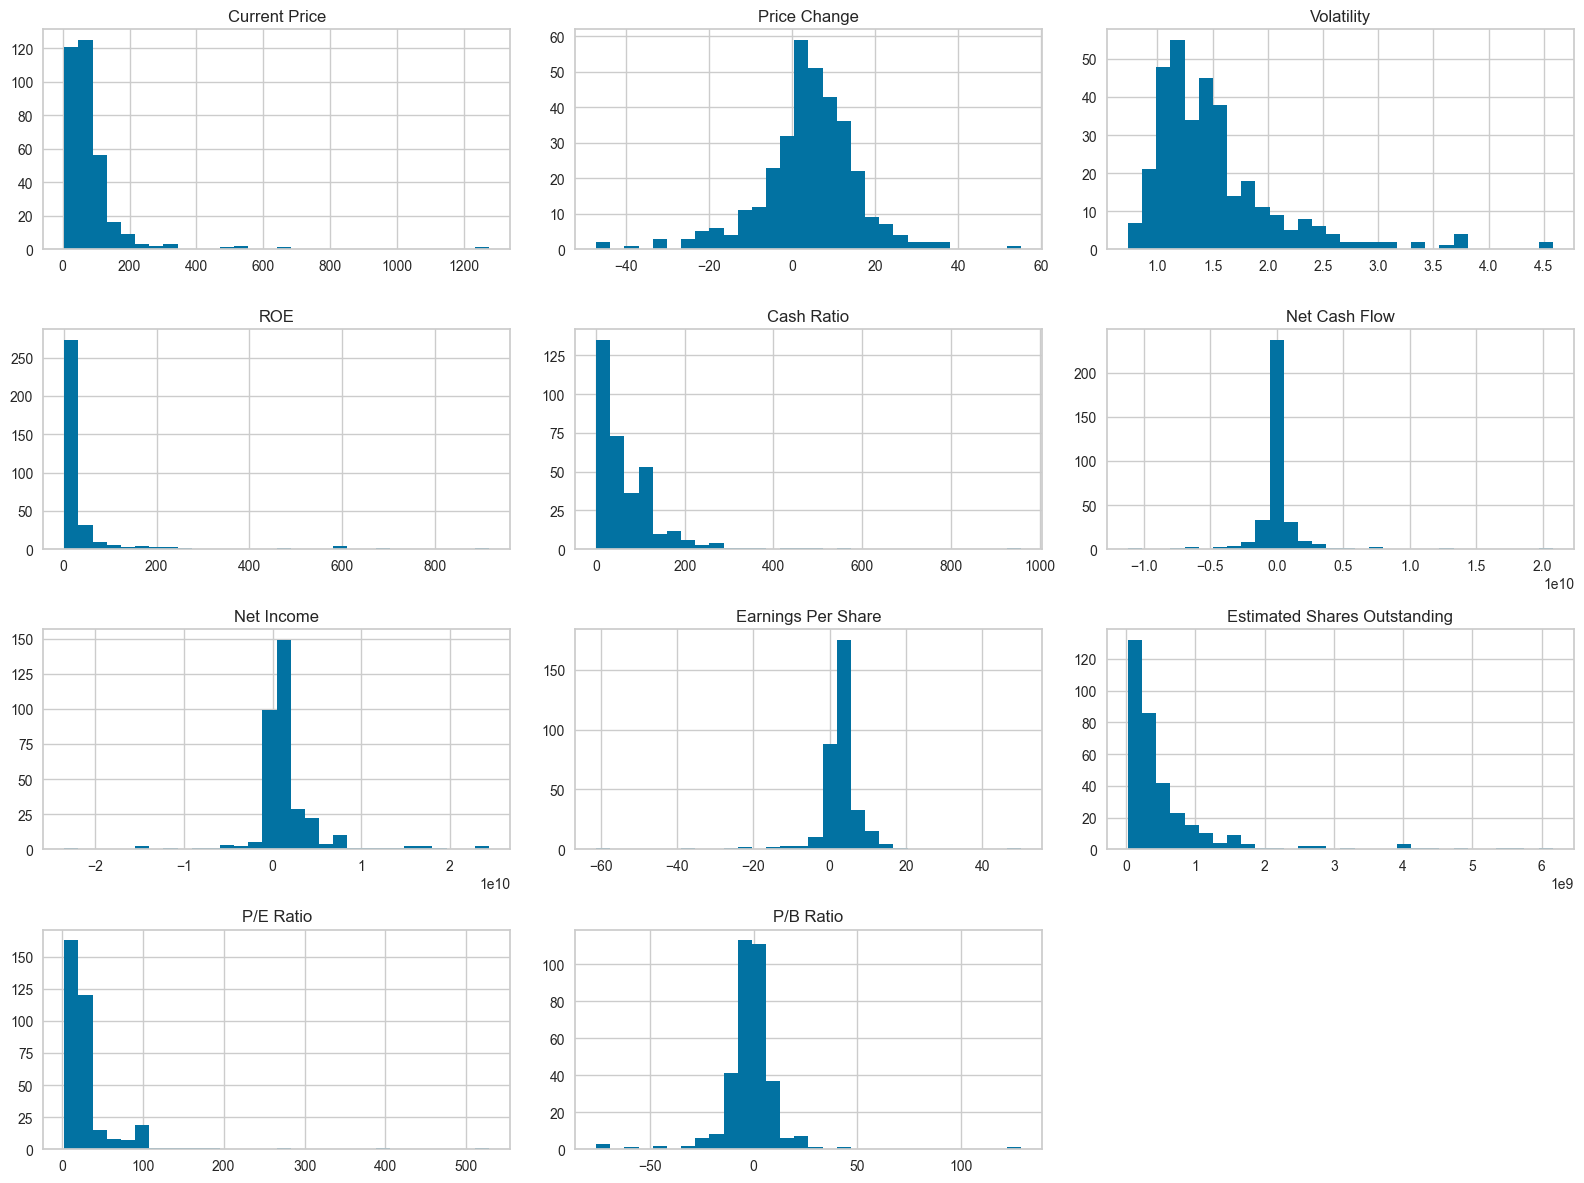

In [10]:
# Select numerical columns
numeric_cols = Trade_df.select_dtypes(include=np.number).columns

# Histograms
Trade_df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

#### Observations

- Current Price is highly right-skewed, with most stocks priced below 200 and a small number of extreme values extending beyond 1,200.
- Price Change is approximately symmetric and centered around 0, with a slight right tail extending toward 40–60.
- Volatility is right-skewed, with most values concentrated between 1.0 and 2.0 and a few higher values extending beyond 3.5.
- ROE is heavily right-skewed, with most values clustered at lower levels and a small number of extreme values extending beyond 500.
- Cash Ratio is right-skewed, with most values below 100 and a long tail extending toward 1,000.
- Net Cash Flow is concentrated around 0, with a small number of extreme values on both the negative and positive sides.
- Net Income is concentrated around lower values, with a few extreme values on both the negative and positive sides.
- Earnings Per Share is concentrated around small positive values, with a long left tail extending toward -60.
- Estimated Shares Outstanding is right-skewed, with most values below 1e9 and a few large values extending beyond 4e9.
- P/E Ratio is right-skewed, with most values below 100 and a small number of extreme values extending toward 500.
- P/B Ratio is concentrated around 0 and is relatively symmetric around the center, with extreme values on both tails extending beyond -50 and 100.

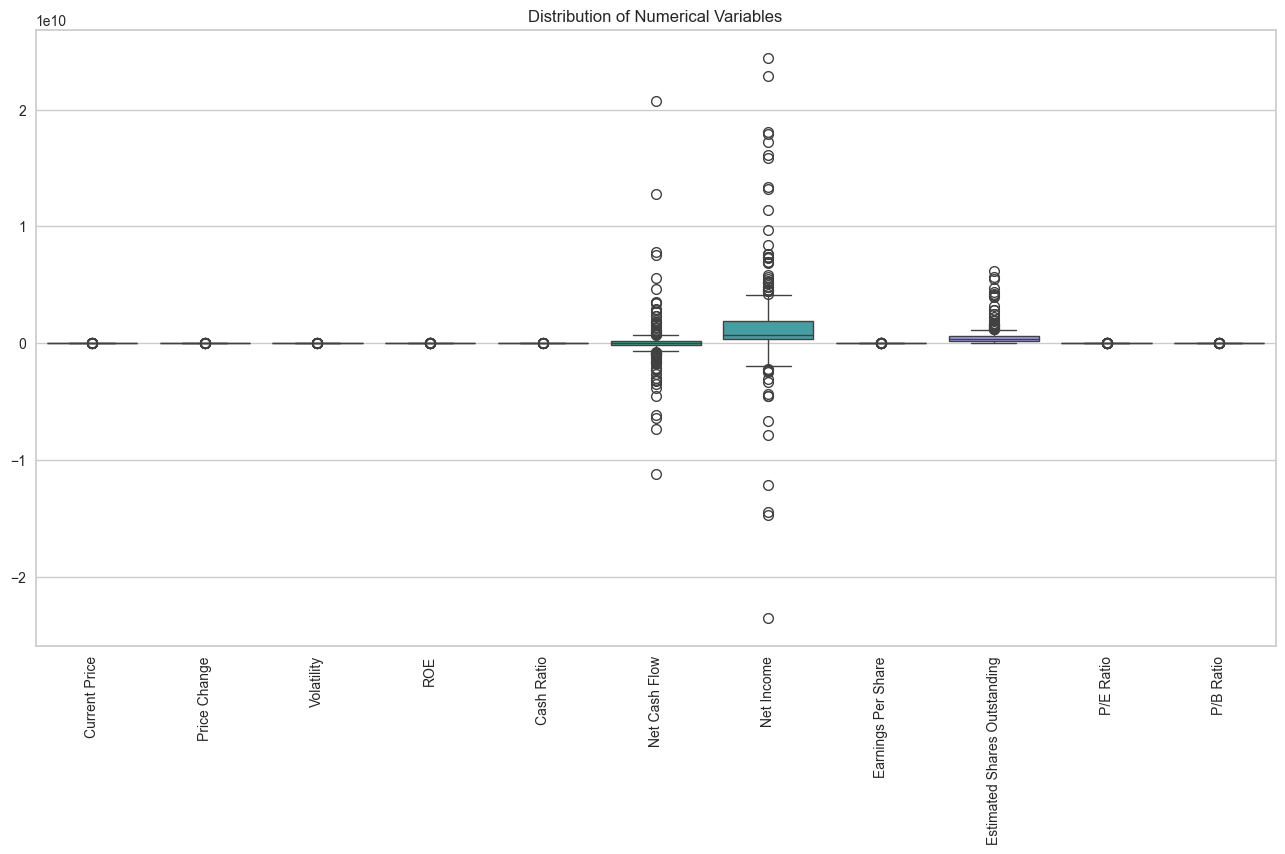

In [11]:
# Box Plot 
plt.figure(figsize=(16, 8))
sns.boxplot(data=Trade_df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Distribution of Numerical Variables")
plt.show()

#### Observations

- The combined boxplot is dominated by Net Cash Flow, Net Income, and Estimated Shares Outstanding, which are on a much larger scale (around 1e10) than the remaining variables.
- Net Income shows the widest spread and the most extreme values, ranging from approximately -2.3e10 to 2.4e10.
- Net Cash Flow also shows a wide spread with extreme values on both the positive and negative sides, ranging from approximately -1.1e10 to 2.1e10.
- Estimated Shares Outstanding has a visible box with extreme values extending up to roughly 6e9, but appears compressed near 0 relative to Net Cash Flow and Net Income.
- Current Price, Price Change, Volatility, ROE, Cash Ratio, Earnings Per Share, P/E Ratio, and P/B Ratio appear compressed near 0 on this scale because their magnitudes are much smaller than the three dominant variables.
- The large difference in scale across variables makes it difficult to compare their distributions directly on a single shared axis.

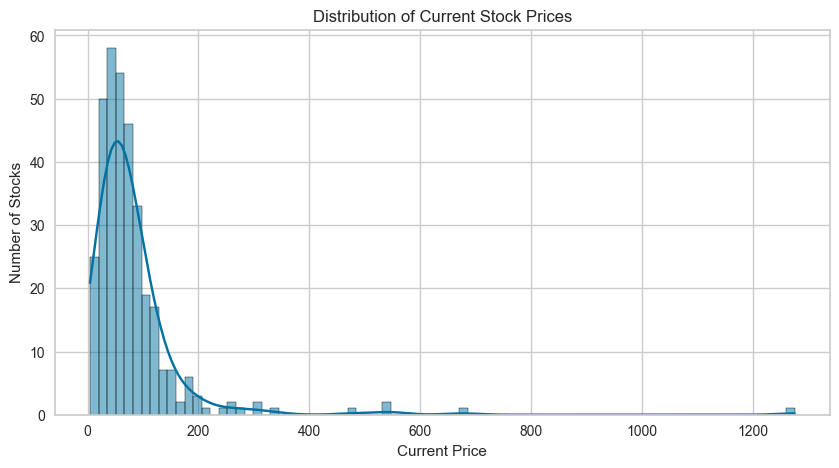

In [12]:
# Plot to show distribution of Current stock prices
plt.figure(figsize=(10, 5))
sns.histplot(Trade_df['Current Price'], kde=True)
plt.title('Distribution of Current Stock Prices')
plt.xlabel('Current Price')
plt.ylabel('Number of Stocks')
plt.show()

#### Observations

- The distribution of Current Price is strongly right-skewed.
- Most stocks are priced between 0 and 150, with the highest concentration around 50–75.
- The density curve shows a peak near 50–60, followed by a steady decline as price increases.
- A long thin tail extends from about 200 to over 1,200, representing a small number of high-priced stocks.
- A few isolated extreme values appear around 480, 550, 680, and 1,275.

### Bivariant Analysis

In [13]:
# Which economic sector has seen the maximum price increase on average?
sector_price_change = (
    Trade_df.groupby('GICS Sector')['Price Change']
    .mean()
    .sort_values(ascending=False)
)

sector_price_change

GICS Sector
Health Care                     9.585652
Consumer Staples                8.684750
Information Technology          7.217476
Telecommunications Services     6.956980
Real Estate                     6.205548
Consumer Discretionary          5.846093
Materials                       5.589738
Financials                      3.865406
Industrials                     2.833127
Utilities                       0.803657
Energy                        -10.228289
Name: Price Change, dtype: float64

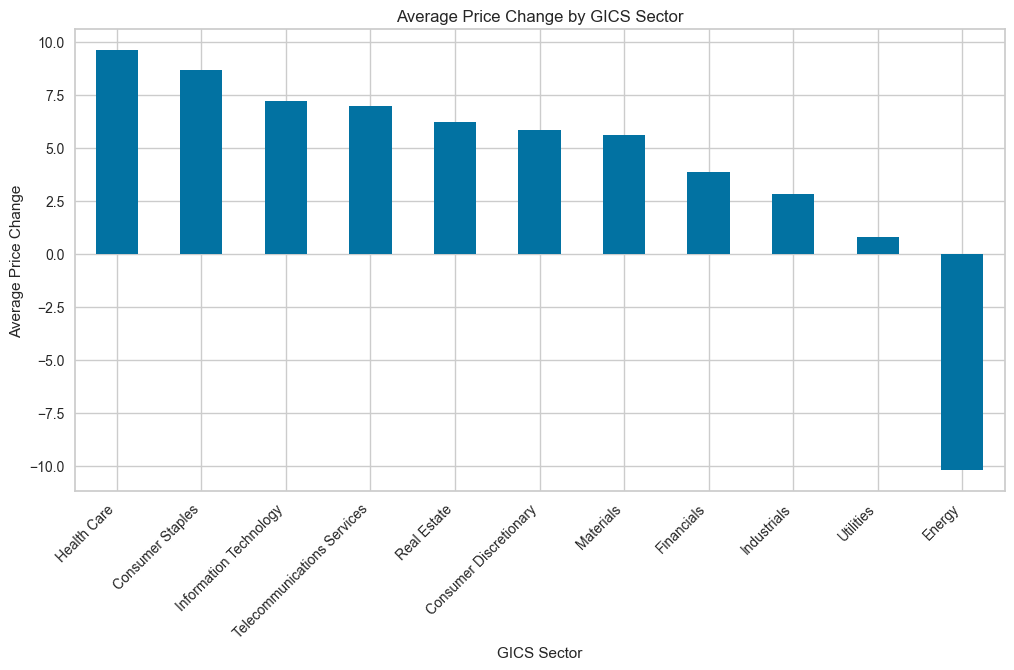

In [14]:
# Ploting the Economic sectors
plt.figure(figsize=(12, 6))
sector_price_change.plot(kind='bar')
plt.title('Average Price Change by GICS Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average Price Change')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observations

- Health Care has the highest average Price Change, followed closely by Consumer Staples.
- Information Technology, Telecommunications Services, Real Estate, Consumer Discretionary, and Materials show moderate positive average Price Changes, ranging from roughly 5.5 to 7.5.
- Financials and Industrials show smaller positive average Price Changes, below 4.
- Utilities shows a slightly positive average Price Change, close to 0.
- Energy is the only sector with a negative average Price Change, at approximately -10.
- Energy's average Price Change is roughly equal in magnitude but opposite in direction to Health Care's.

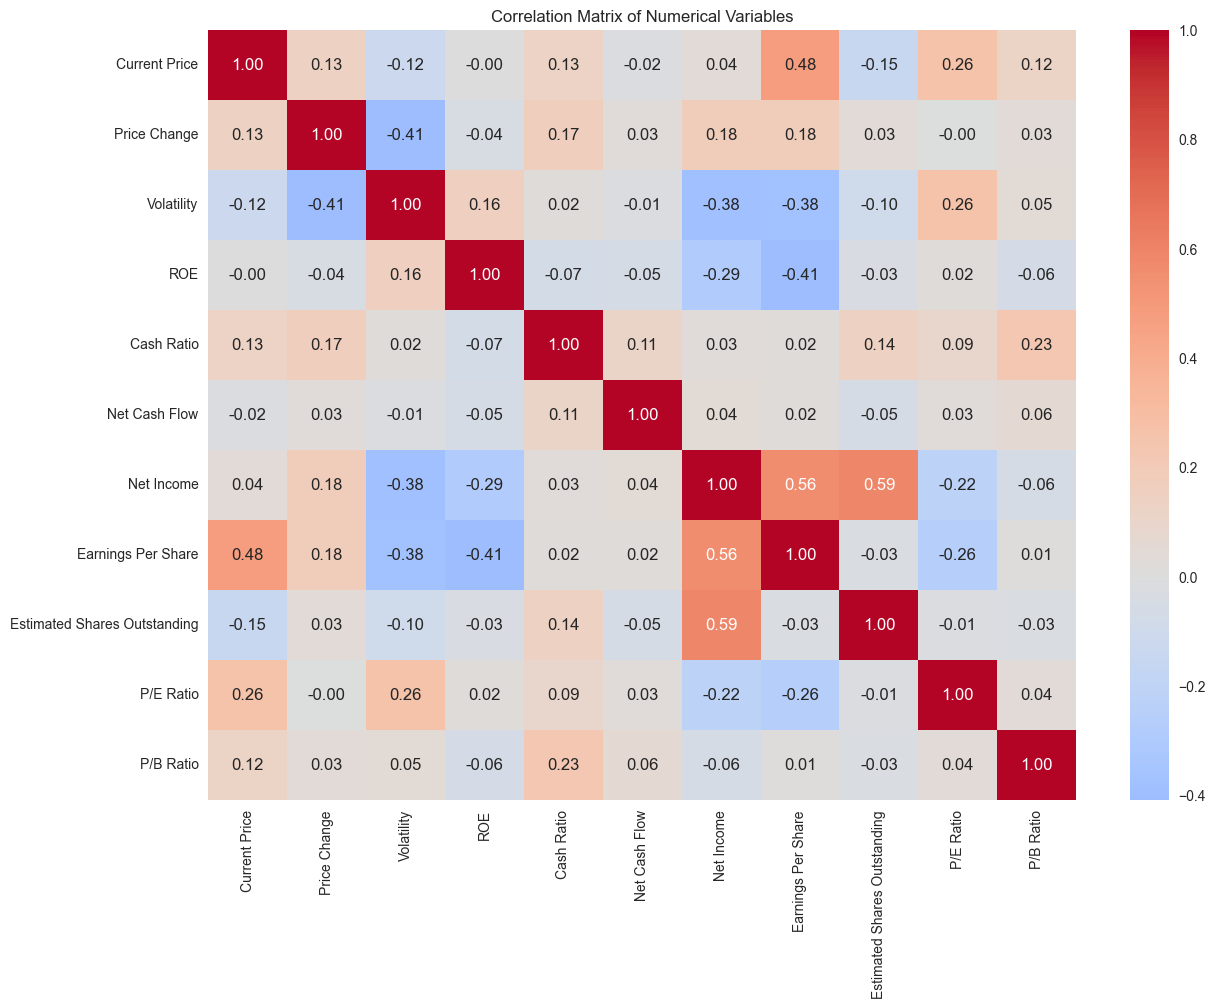

In [15]:
# How are the different variables correlated with each other?

plt.figure(figsize=(14, 10))

corr = Trade_df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

#### Observations

- Current Price and Earnings Per Share show the strongest positive correlation among the variable pairs, at 0.48.
- Net Income shows moderate positive correlations with both Earnings Per Share (0.56) and Estimated Shares Outstanding (0.59).
- Earnings Per Share and ROE show a moderate negative correlation of -0.41.
- Volatility shows negative correlations with Price Change (-0.41), Net Income (-0.38), and Earnings Per Share (-0.38).
- ROE shows negative correlations with Net Income (-0.29) and Earnings Per Share (-0.41).
- P/E Ratio shows negative correlations with Net Income (-0.22) and Earnings Per Share (-0.26), and a positive correlation with Volatility (0.26).
- Most of the remaining variable pairs show weak correlations, generally ranging between -0.15 and 0.20.
- Net Cash Flow shows weak correlations with nearly all other variables, with none exceeding 0.11 in magnitude.

In [16]:
# Cash Ratio By Sector

cash_ratio_sector = (
    Trade_df.groupby('GICS Sector')['Cash Ratio']
    .mean()
    .sort_values(ascending=False)
)

cash_ratio_sector

GICS Sector
Information Technology         149.818182
Telecommunications Services    117.000000
Health Care                    103.775000
Financials                      98.591837
Consumer Staples                70.947368
Energy                          51.133333
Real Estate                     50.111111
Consumer Discretionary          49.575000
Materials                       41.700000
Industrials                     36.188679
Utilities                       13.625000
Name: Cash Ratio, dtype: float64

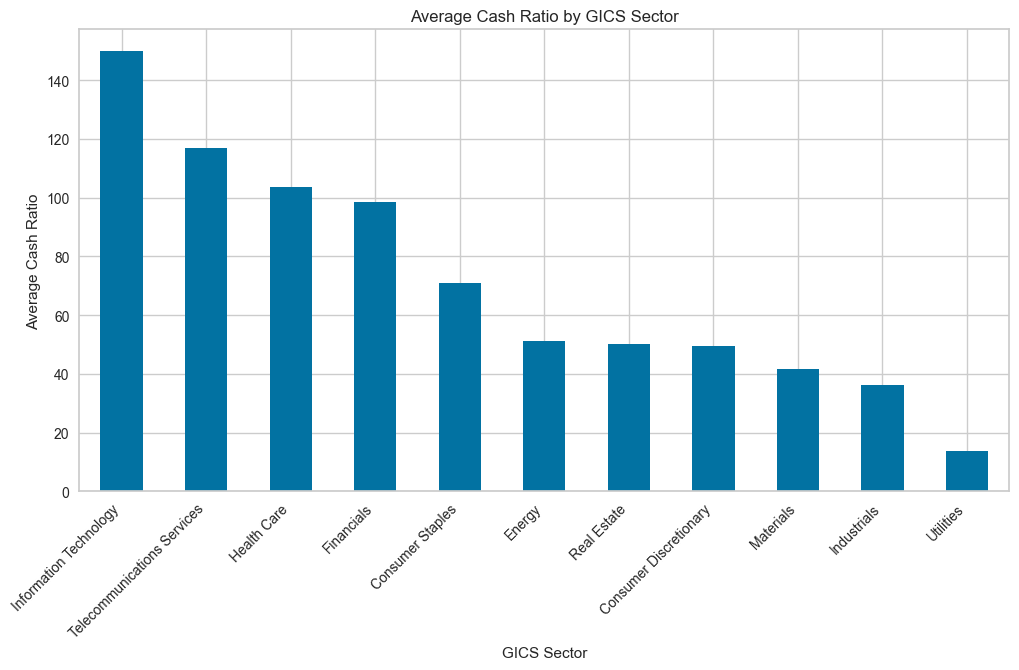

In [17]:
# Plot 
plt.figure(figsize=(12, 6))

cash_ratio_sector.plot(kind='bar')

plt.title('Average Cash Ratio by GICS Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average Cash Ratio')
plt.xticks(rotation=45, ha='right')

plt.show()

#### Observations

- Information Technology has the highest average Cash Ratio, at approximately 150.
- Telecommunications Services, Health Care, and Financials also show relatively high average Cash Ratios, ranging from about 100 to 117.
- Consumer Staples has a moderate average Cash Ratio of around 71.
- Energy, Real Estate, and Consumer Discretionary show similar average Cash Ratios, clustered close to 50.
- Materials and Industrials show lower average Cash Ratios, around 37–42.
- Utilities has the lowest average Cash Ratio, at approximately 14.
- Overall, the average Cash Ratio varies considerably across sectors, with Information Technology having the highest value and Utilities having the lowest.

In [18]:
# P/E Ratio by Sector
pe_sector = (
    Trade_df.groupby('GICS Sector')['P/E Ratio']
    .mean()
    .sort_values(ascending=False)
)

pe_sector

GICS Sector
Energy                         72.897709
Information Technology         43.782546
Real Estate                    43.065585
Health Care                    41.135272
Consumer Discretionary         35.211613
Consumer Staples               25.521195
Materials                      24.585352
Utilities                      18.719412
Industrials                    18.259380
Financials                     16.023151
Telecommunications Services    12.222578
Name: P/E Ratio, dtype: float64

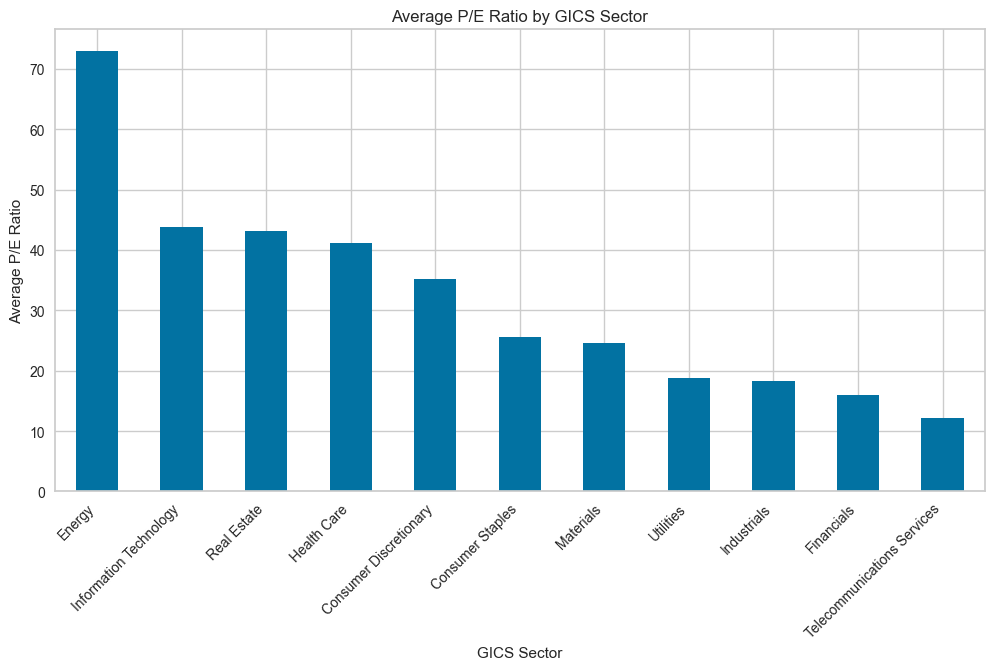

In [19]:
# Plot 
plt.figure(figsize=(12, 6))

pe_sector.plot(kind='bar')

plt.title('Average P/E Ratio by GICS Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average P/E Ratio')
plt.xticks(rotation=45, ha='right')

plt.show()

#### Observations:

* Energy has the highest average P/E ratio, at approximately 73, noticeably higher than all other sectors.
* Information Technology, Real Estate, and Health Care show the next highest average P/E ratios, clustered between roughly 41 and 44.
* Consumer Discretionary shows a moderate average P/E ratio of around 35.
* Consumer Staples and Materials show similar average P/E ratios, close to 25.
* Utilities, Industrials, and Financials show lower average P/E ratios, ranging from about 16 to 19.
* Telecommunications Services has the lowest average P/E ratio, at approximately 12.
* Energy had a negative average Price Change in the earlier sector analysis, while having the highest average P/E ratio in this analysis.


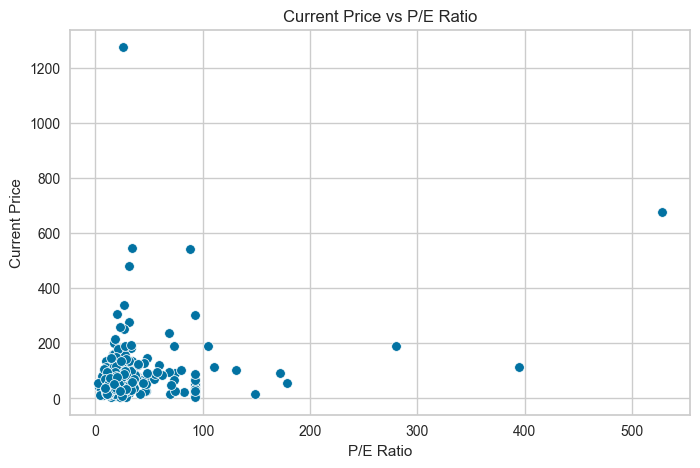

In [20]:
# Current Price vs P/E Ratio

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=Trade_df,
    x='P/E Ratio',
    y='Current Price'
)

plt.title('Current Price vs P/E Ratio')
plt.show()

#### Observations:

* The majority of stocks are concentrated in a dense cluster with P/E Ratio below 100 and Current Price below 200.
* A few points show high Current Price despite low to moderate P/E Ratio, including one extreme point near a P/E Ratio of 25 and a Current Price of about 1,275.
* One point shows a high P/E Ratio of around 525 paired with a moderate Current Price of about 675.
* Points with P/E Ratio above 250, including those around 280 and 395, show relatively low Current Price values below 200.
* There is no clear linear relationship visible between Current Price and P/E Ratio across the full range of the data.


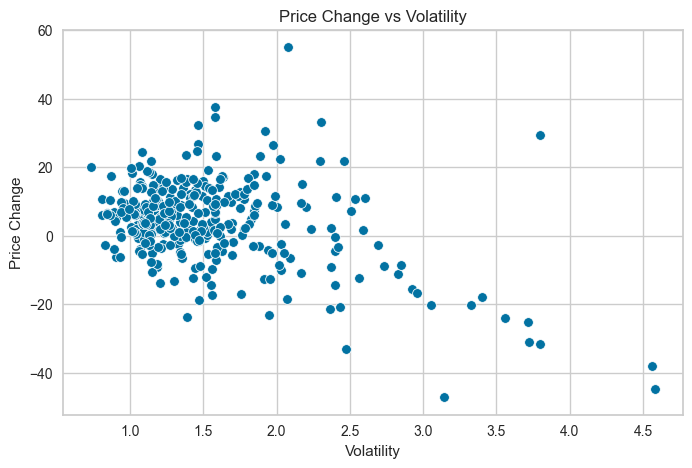

In [21]:
# Price change vs Volatility
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=Trade_df,
    x='Volatility',
    y='Price Change'
)

plt.title('Price Change vs Volatility')
plt.show()

#### Observations:

* Most points are concentrated in the Volatility range of about 0.7 to 2.0, with Price Change values spread roughly between -20 and 30.
* As Volatility increases beyond about 2.5, Price Change values tend to be more negative, with a wider spread.
* The most negative Price Change values, below -30, occur at Volatility levels above 2.0.
* At the highest Volatility levels, around 3.5 to 4.6, most points show negative Price Change, with a few reaching as low as about -45.
* One point near a Volatility of 3.8 shows a positive Price Change of about 30, in contrast to nearby points.
* The highest Price Change value, around 55, occurs at a moderate Volatility of about 2.1.
* Overall, the plot suggests a negative association between Volatility and Price Change, particularly at higher Volatility levels.


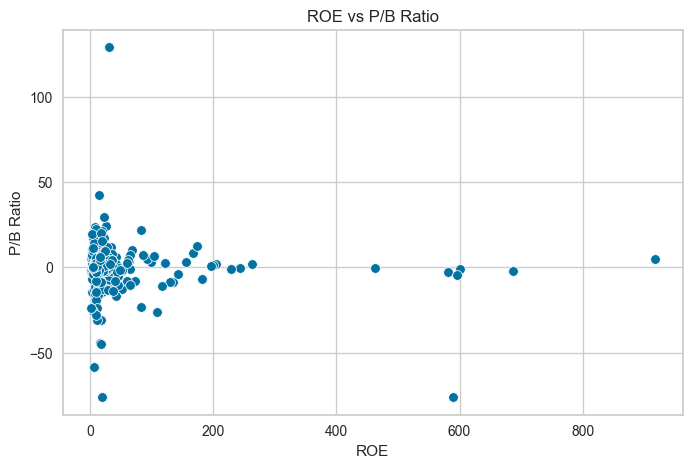

In [22]:
# ROE vs P/E Ratio
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=Trade_df,
    x='ROE',
    y='P/B Ratio'
)

plt.title('ROE vs P/B Ratio')
plt.show()

#### Observations:

* The majority of points are concentrated at low ROE values, below about 50, with P/B Ratio values spread roughly between -60 and 40.
* One point near an ROE of about 25 shows a notably high P/B Ratio of around 130.
* A small number of points extend to high ROE values, ranging from about 450 to 920, with P/B Ratio values close to 0 in most cases.
* One point near an ROE of about 590 shows a P/B Ratio of about -75, which is an extreme value compared to other high-ROE points.
* The spread of P/B Ratio narrows considerably as ROE increases beyond about 200.
* There is no clear linear relationship visible between ROE and P/B Ratio across the full range of the data.


## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

In [23]:
# Duplicate check
Trade_df.duplicated().sum()

0

* No duplicate observations were identified.

In [24]:
#Check for missing values
Trade_df.isnull().sum()

Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64

* No missing values were identified in the dataset; therefore, no missing value treatment was required.

In [25]:
# Checking outliers
outlier_counts = {}

for col in numeric_cols:
    Q1 = Trade_df[col].quantile(0.25)
    Q3 = Trade_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_counts[col] = ((Trade_df[col] < lower) | 
                           (Trade_df[col] > upper)).sum()

pd.Series(outlier_counts).sort_values(ascending=False)

Net Cash Flow                   76
Net Income                      57
P/E Ratio                       41
ROE                             39
Earnings Per Share              39
Estimated Shares Outstanding    35
P/B Ratio                       30
Price Change                    23
Current Price                   22
Volatility                      20
Cash Ratio                      16
dtype: int64

##### Observations

* Net Cash Flow has the highest number of potential outliers, with 76 observations, followed by Net Income with 57.
* P/E Ratio (41), ROE (39), and Earnings Per Share (39) also have relatively high numbers of potential outliers.
* Estimated Shares Outstanding has 35 potential outliers, while P/B Ratio has 30.
* Price Change (23), Current Price (22), and Volatility (20) have fewer potential outliers.
* Cash Ratio has the lowest number of potential outliers, with 16 observations.
* All 11 numerical variables contain observations classified as potential outliers using the 1.5 × IQR rule, with counts ranging from 16 to 76.
* These are potential outliers identified using the IQR rule and do not necessarily represent data errors or observations that should be removed.

##### Treatment

The identified potential outliers were retained because extreme financial values may represent genuine differences in the characteristics and performance of companies rather than data-entry errors. Removing them could result in the loss of meaningful information.



In [26]:
# Feature Selection for Clustering 
cluster_cols = [
    'Current Price',
    'Price Change',
    'Volatility',
    'ROE',
    'Cash Ratio',
    'Net Cash Flow',
    'Net Income',
    'Earnings Per Share',
    'Estimated Shares Outstanding',
    'P/E Ratio',
    'P/B Ratio'
]
Trade_df[cluster_cols].corr().round(2)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
Current Price,1.00,0.13,-0.12,-0.00,0.13,-0.02,0.04,0.48,-0.15,0.26,0.12
Price Change,0.13,1.00,-0.41,-0.04,0.17,0.03,0.18,0.18,0.03,-0.00,0.03
Volatility,-0.12,-0.41,1.00,0.16,0.02,-0.01,-0.38,-0.38,-0.10,0.26,0.05
ROE,-0.00,-0.04,0.16,1.00,-0.07,-0.05,-0.29,-0.41,-0.03,0.02,-0.06
Cash Ratio,0.13,0.17,0.02,-0.07,1.00,0.11,0.03,0.02,0.14,0.09,0.23
Net Cash Flow,-0.02,0.03,-0.01,-0.05,0.11,1.00,0.04,0.02,-0.05,0.03,0.06
Net Income,0.04,0.18,-0.38,-0.29,0.03,0.04,1.00,0.56,0.59,-0.22,-0.06
Earnings Per Share,0.48,0.18,-0.38,-0.41,0.02,0.02,0.56,1.00,-0.03,-0.26,0.01
Estimated Shares Outstanding,-0.15,0.03,-0.10,-0.03,0.14,-0.05,0.59,-0.03,1.00,-0.01,-0.03
P/E Ratio,0.26,-0.00,0.26,0.02,0.09,0.03,-0.22,-0.26,-0.01,1.00,0.04


##### Correlation Check

The correlation matrix from the bivariate analysis was reviewed to assess relationships among the numerical variables before clustering. No extremely high correlations were identified that would require automatic removal of a feature. Therefore, the selected numerical financial variables were retained for clustering.

The final features were selected based on their relevance to stock price performance, risk, profitability, liquidity, cash flow, earnings, and valuation.


In [27]:
Trade_df[cluster_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.0,8.086234e+01,9.805509e+01,4.500000e+00,3.855500e+01,5.970500e+01,9.288000e+01,1.274950e+03
Price Change,340.0,4.078194e+00,1.200634e+01,-4.712969e+01,-9.394838e-01,4.819505e+00,1.069549e+01,5.505168e+01
Volatility,340.0,1.525976e+00,5.917984e-01,7.331632e-01,1.134878e+00,1.385593e+00,1.695549e+00,4.580042e+00
ROE,340.0,3.959706e+01,9.654754e+01,1.000000e+00,9.750000e+00,1.500000e+01,2.700000e+01,9.170000e+02
Cash Ratio,340.0,7.002353e+01,9.042133e+01,0.000000e+00,1.800000e+01,4.700000e+01,9.900000e+01,9.580000e+02
Net Cash Flow,340.0,5.553762e+07,1.946365e+09,-1.120800e+10,-1.939065e+08,2.098000e+06,1.698108e+08,2.076400e+10
Net Income,340.0,1.494385e+09,3.940150e+09,-2.352800e+10,3.523012e+08,7.073360e+08,1.899000e+09,2.444200e+10
Earnings Per Share,340.0,2.776662e+00,6.587779e+00,-6.120000e+01,1.557500e+00,2.895000e+00,4.620000e+00,5.009000e+01
Estimated Shares Outstanding,340.0,5.770283e+08,8.458496e+08,2.767216e+07,1.588482e+08,3.096751e+08,5.731175e+08,6.159292e+09
P/E Ratio,340.0,3.261256e+01,4.434873e+01,2.935451e+00,1.504465e+01,2.081988e+01,3.176476e+01,5.280391e+02


##### Observations

* The selected clustering features have substantially different scales and ranges.
* Current Price, Net Cash Flow, Net Income, and Estimated Shares Outstanding show particularly large differences in magnitude compared with variables such as Volatility, ROE, Cash Ratio, P/E Ratio, and P/B Ratio.
* Net Cash Flow and Net Income have very large standard deviations and wide ranges, indicating substantial variation across the stocks.
* ROE and P/E Ratio have means considerably higher than their medians, suggesting the presence of right-skewed distributions and extreme values.
* P/B Ratio contains both negative and positive values and has a wide range, indicating substantial variation across companies.
* These differences in scale and variability indicate that feature scaling is necessary before applying distance-based clustering methods.


In [28]:
# Feature Scaling 
scaler = StandardScaler()

X = Trade_df[cluster_cols]

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_cols,
    index=Trade_df.index
)

X_scaled.head()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196


In [29]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.0,7.836868e-18,1.001474,-0.779918,-0.432101,-0.216088,0.122741,12.195670
Price Change,340.0,-2.873518e-17,1.001474,-4.271357,-0.418535,0.061834,0.551963,4.251806
Volatility,340.0,-7.967483e-17,1.001474,-1.341642,-0.661838,-0.237564,0.286960,5.168258
ROE,340.0,2.873518e-17,1.001474,-0.400362,-0.309599,-0.255142,-0.130667,9.101176
Cash Ratio,340.0,-8.098097e-17,1.001474,-0.775555,-0.576194,-0.255000,0.320933,9.834905
Net Cash Flow,340.0,2.612289e-18,1.001474,-5.795489,-0.128348,-0.027497,0.058798,10.655237
Net Income,340.0,1.044916e-17,1.001474,-6.359977,-0.290285,-0.200045,0.102842,5.832629
Earnings Per Share,340.0,5.747037e-17,1.001474,-9.725729,-0.185337,0.017990,0.280224,7.192572
Estimated Shares Outstanding,340.0,-1.044916e-16,1.001474,-0.650430,-0.495119,-0.316542,-0.004630,6.609320
P/E Ratio,340.0,7.836868e-18,1.001474,-0.670162,-0.396715,-0.266300,-0.019145,11.187619


##### Observations

* The dataset contains 340 observations for each of the 11 selected clustering features.
* The mean of each standardized feature is approximately 0, confirming that the variables have been centered around their respective means.
* The standard deviation of each feature is approximately 1, confirming that the variables have been standardized to a comparable scale.
* Some features still contain extreme standardized values. For example, Earnings Per Share has a minimum of -9.73, Net Income has a minimum of -6.36, and Net Cash Flow has a minimum of -5.80.
* Several variables also have high positive standardized values, including Current Price (12.20), Net Cash Flow (10.66), P/E Ratio (11.19), and Cash Ratio (9.83).
* These extreme standardized values reflect the underlying variation and potential outliers identified during the earlier exploratory analysis; scaling changes the scale of the variables but does not remove outliers.
* Despite the differences in their original units and ranges, all selected features are now on a comparable standardized scale, making them suitable for distance-based clustering methods.



## EDA

- It is a good idea to explore the data once again after manipulating it.

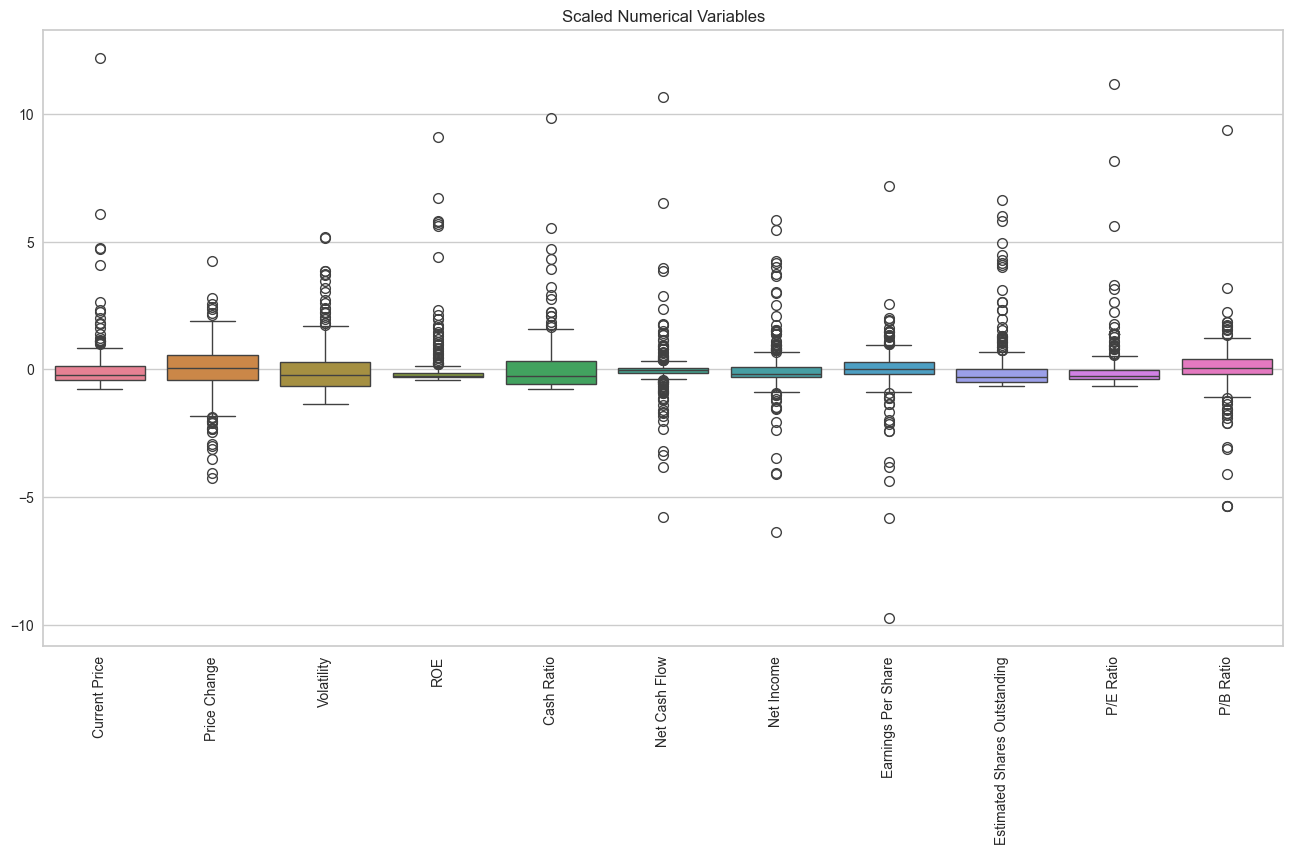

In [30]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=X_scaled)

plt.xticks(rotation=90)
plt.title('Scaled Numerical Variables')
plt.show()

##### Observations

* All variables are now on a comparable scale after standardization, allowing their distributions to be visually compared more effectively.
* All 11 variables contain potential outliers, consistent with the earlier IQR-based outlier analysis.
* Earnings Per Share has the widest range of standardized values, extending from approximately -9.8 to 7.2.
* Current Price has a maximum standardized value of approximately 12.2, the highest positive value among the variables.
* P/E Ratio has a maximum standardized value of approximately 11.2.
* Price Change and Volatility show comparatively narrower ranges of standardized values than most of the other variables.
* Net Cash Flow, Net Income, and Earnings Per Share show extreme standardized values on both the positive and negative sides.
* P/B Ratio has extreme standardized values on both sides, reaching approximately 9.4 on the positive side and -5.3 on the negative side.
* Cash Ratio has a relatively wider central box than several other variables, while its extreme standardized values are less pronounced than those of variables such as Earnings Per Share and Current Price.


After standardization, the numerical variables are placed on a comparable scale, preventing variables with larger magnitudes from dominating distance calculations during clustering.


## K-means Clustering

In [31]:
# Step 1 Choose a range of K
k_range = range(2, 11)

inertia = []
silhouette_scores = []

In [32]:
# Step 2 Calculate the Elbow curve and Silhoutte scores
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

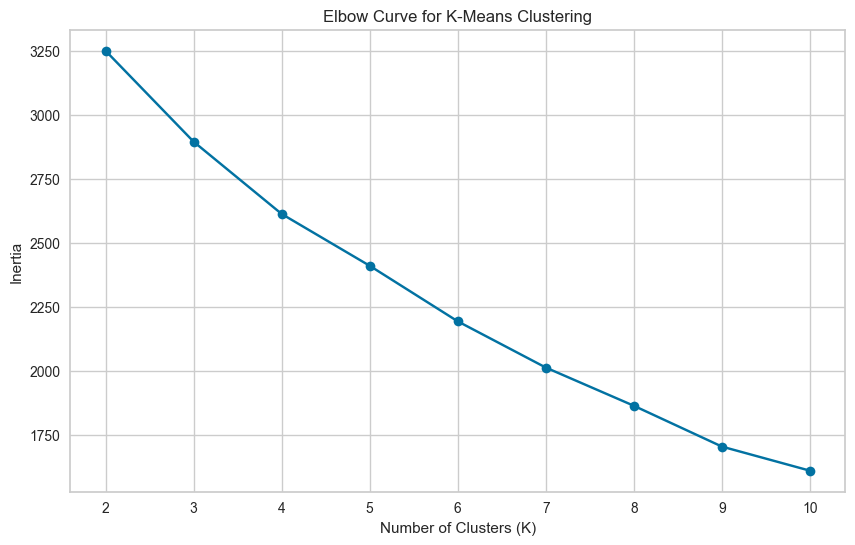

In [33]:
# Step 3 Plot the Elbow Curve
plt.figure(figsize=(10, 6))

plt.plot(k_range, inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-Means Clustering')
plt.xticks(list(k_range))
plt.show()

#### Observations

* Inertia decreases steadily as the number of clusters (K) increases, from approximately 3250 at K=2 to approximately 1610 at K=10.
* The largest reduction in inertia occurs between K=2 and K=4, where inertia decreases from approximately 3250 to approximately 2615.
* The rate of decrease becomes less steep between K=4 and K=7, with inertia declining from approximately 2615 to approximately 2015.
* A visible bend in the curve appears around K=4 to K=5, where the rate of decrease starts to become less pronounced.
* From K=7 to K=10, inertia continues to decrease, but at a more gradual and relatively consistent rate.
* No single sharp elbow point is clearly visible, as the curve shows a gradual decline across the range of K values.


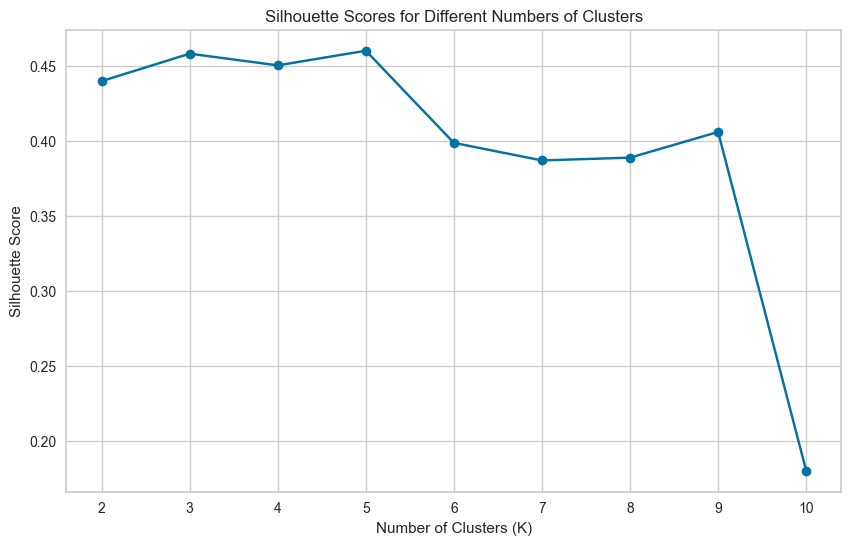

In [34]:
# Step 4 Plot the Silhoutte scores

plt.figure(figsize=(10, 6))

plt.plot(k_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xticks(list(k_range))
plt.show()

### Observations

* The silhouette score reaches its highest value at K=5, at approximately 0.46.
* Scores remain relatively high and close together for K=2 through K=5, ranging from approximately 0.44 to 0.46.
* A noticeable drop occurs between K=5 and K=6, where the score decreases from approximately 0.46 to 0.40.
* Scores remain relatively stable between K=6 and K=8, ranging from approximately 0.39 to 0.40.
* A slight increase occurs at K=9, with the silhouette score reaching approximately 0.41.
* The score drops sharply at K=10 to approximately 0.18, which is the lowest value across all K values tested.


In [35]:
# Step 5 Creating a table to compare K values

k_results = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})

k_results


,K,Inertia,Silhouette Score
0,2,3252.045921,0.439696
1,3,2896.599821,0.457977
2,4,2614.030174,0.450179
3,5,2411.340948,0.459935
4,6,2194.081746,0.398538
5,7,2013.370110,0.386848
6,8,1863.986085,0.388693
7,9,1704.423822,0.405810
8,10,1610.197897,0.180115


### Observations:

* The inertia decreases consistently as the number of clusters (K) increases from 2 to 10, indicating that the within-cluster variation decreases as more clusters are added.
* The silhouette score is highest at K=5, with a score of approximately 0.46.
* Silhouette scores remain relatively high and close together for K=2 to K=5, ranging from approximately 0.44 to 0.46.
* A noticeable decrease in the silhouette score occurs from K=5 to K=6, where the score drops from approximately 0.46 to 0.40.
* The silhouette score continues to decline for K=7 and K=8, with values of approximately 0.39.
* The score increases slightly at K=9 to approximately 0.41 before dropping sharply to approximately 0.18 at K=10.
* Based on the highest silhouette score, K=5 provides highest silhouette score among the K values tested.


#### Step 6 Choose the Appropriate K 


The Elbow Method and Silhouette Analysis were used together to determine an appropriate number of clusters. The Elbow Curve showed a gradual decrease in inertia, with a visible bend around K=4 to K=5, although no single sharp elbow point was identified.

The silhouette analysis showed that K=5 achieved the highest silhouette score of approximately 0.46 among the values tested. The score also decreased noticeably after K=5, particularly at K=6.

Based on the combined results of the Elbow Method and Silhouette Analysis, K=5 was selected as the appropriate number of clusters for the K-means model.


In [36]:
# Step 7 Fit the final K-means Model

optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [37]:
# Step 8 Assign Clusters 
Trade_df['KMeans_Cluster'] = kmeans.labels_

Trade_df['KMeans_Cluster'].value_counts().sort_index()


0     11
1     13
2    280
3     29
4      7
Name: KMeans_Cluster, dtype: int64

In [38]:
cluster_distribution = (
    Trade_df['KMeans_Cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution

0     3.24
1     3.82
2    82.35
3     8.53
4     2.06
Name: KMeans_Cluster, dtype: float64

In [39]:
# Step 9 Visualize the clusters


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = Trade_df['KMeans_Cluster']

pca_df.head()

,PC1,PC2,Cluster
0,-1.228300,-0.915282,2
1,-0.132905,-1.024312,2
2,-1.071312,-0.751996,2
3,-0.126537,1.176945,2
4,0.576854,1.113511,1


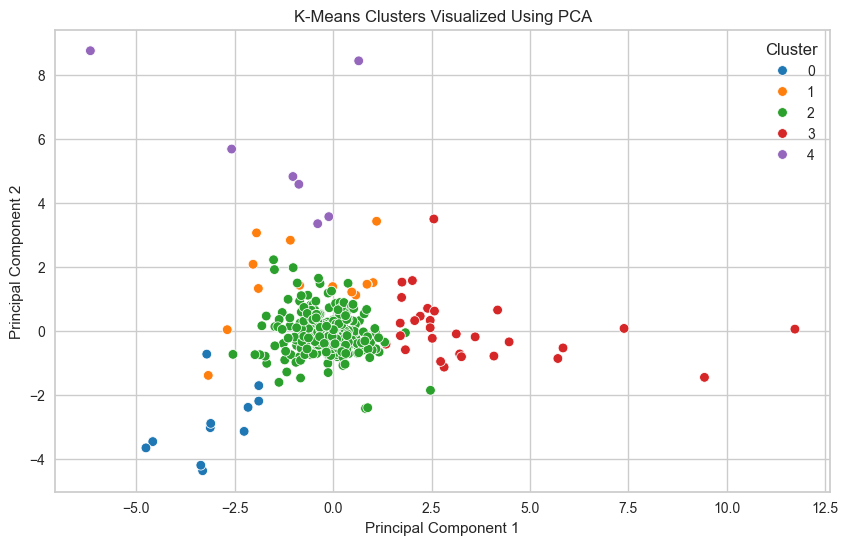

In [40]:
# Ploting 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10'
)

plt.title('K-Means Clusters Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#### Observations:

* Cluster 2 (green) forms the largest and densest group, concentrated near the center of the plot, around Principal Component 1 values of -2 to 1 and Principal Component 2 values of -2 to 2.
* Cluster 3 (red) is spread across a wide range of Principal Component 1 values, extending from about 0 to 11.7, while Principal Component 2 values remain generally close to 0.
* Cluster 1 (orange) is positioned mostly to the left and slightly above the center, with Principal Component 1 values roughly between -3 and 1 and Principal Component 2 values between -1.5 and 3.5.
* Cluster 0 (blue) forms a small, distinct group at negative Principal Component 1 and Principal Component 2 values, roughly between -5 and -3 on the x-axis and -4.5 and -3 on the y-axis.
* Cluster 4 (purple) contains a small number of points at higher Principal Component 2 values, including extreme points near (-6, 8.7) and (-2.3, 5.7).
* Some overlap is visible between Cluster 1 and Cluster 2 near the center of the plot.
* The points furthest to the right along Principal Component 1 all belong to Cluster 3.


In [41]:
# Step 10 Profile the clusters

cluster_profile = Trade_df.groupby('KMeans_Cluster')[cluster_cols].mean()

cluster_profile

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
KMeans_Cluster,,,,,,,,,,,
0,50.477272,5.588148,1.141171,31.545455,64.181818,-2.581727e+09,1.467555e+10,4.490909,4.012176e+09,14.010093,-5.356393
1,81.418719,10.536341,1.578634,17.000000,367.538462,3.857063e+09,3.129068e+09,2.197692,1.334755e+09,65.639418,6.235848
2,73.769121,5.466467,1.392827,34.632143,55.710714,4.183132e+06,1.443269e+09,3.629625,4.302171e+08,24.132318,-3.203999
3,38.808966,-13.680395,2.938240,106.034483,55.551724,-1.898257e+08,-3.578127e+09,-8.657586,4.631212e+08,85.946813,1.888901
4,585.527134,7.752090,1.508020,17.571429,159.142857,2.105204e+08,8.045904e+08,14.410000,1.160806e+08,118.763084,33.713020


#### Observations

* Cluster 0 has a relatively low average Current Price of about 50.48 and a negative average Net Cash Flow of approximately -2.58 billion. However, it has a high average Net Income of about 14.68 billion. It also has a relatively low average P/E Ratio of 14.01 and a negative average P/B Ratio of -5.36.
* Cluster 1 has an average Current Price of about 81.42 and the highest average Cash Ratio among the clusters, at approximately 367.54. It also has a relatively high average P/E Ratio of 65.64 and a positive average P/B Ratio of 6.24.
* Cluster 2 has intermediate values across most variables, with an average Current Price of about 73.77, ROE of 34.63, and P/E Ratio of 24.13. Its average Net Cash Flow is close to zero relative to the other clusters.
* Cluster 3 has the lowest average Current Price, at about 38.81, and the most negative average Price Change, at approximately -13.68. It also has the highest average Volatility of 2.94 and the highest average ROE of 106.03. In addition, it has negative average Net Income of approximately -3.58 billion and negative average Earnings Per Share of approximately -8.66.
* Cluster 4 is characterized by a very high average Current Price of approximately 585.53, the highest among all clusters. It also has the highest average Earnings Per Share of 14.41, P/E Ratio of 118.76, and P/B Ratio of 33.71, along with a relatively high average Cash Ratio of 159.14.
* Overall, the clusters exhibit distinct financial profiles, particularly in terms of Current Price, Price Change, Volatility, Cash Ratio, profitability measures, and valuation ratios.


In [42]:
# Step 11 Examine cluster sizes
cluster_sizes = (
    Trade_df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

cluster_sizes

0     11
1     13
2    280
3     29
4      7
Name: KMeans_Cluster, dtype: int64

In [43]:
cluster_summary = pd.DataFrame({
    'Count': Trade_df['KMeans_Cluster'].value_counts().sort_index(),
    'Percentage': (
        Trade_df['KMeans_Cluster']
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

cluster_summary

,Count,Percentage
0,11,3.24
1,13,3.82
2,280,82.35
3,29,8.53
4,7,2.06


#### Observations

* Cluster 2 contains the majority of observations, with 280 companies, representing approximately 82.35% of the dataset.
* Cluster 3 contains 29 companies, representing approximately 8.53% of the dataset.
* Cluster 1 contains 13 companies, representing approximately 3.82% of the dataset.
* Cluster 0 contains 11 companies, representing approximately 3.24% of the dataset.
* Cluster 4 is the smallest cluster, containing 7 companies, which represents approximately 2.06% of the dataset.
* Overall, the clusters are highly imbalanced, with Cluster 2 containing the large majority of companies while the remaining clusters contain relatively few observations.


### Step 12 Interpretation of Clusters

The K-means clustering results indicate that the companies can be grouped into five clusters with distinct financial characteristics.

* Cluster 0 is characterized by relatively low Current Price, negative Net Cash Flow, high Net Income, and a negative P/B Ratio.
* Cluster 1 is distinguished by a very high Cash Ratio, relatively high P/E Ratio, and positive P/B Ratio.
* Cluster 2 represents the largest group of companies and generally has intermediate values across most of the financial variables.
* Cluster 3 is characterized by the lowest Current Price, the most negative Price Change, high Volatility, and negative Net Income and Earnings Per Share.
* Cluster 4 is characterized by a substantially higher Current Price, Earnings Per Share, P/E Ratio, and P/B Ratio compared with the other clusters.

Overall, the clustering identifies groups of companies with different combinations of price, performance, risk, profitability, liquidity, and valuation characteristics. The large size of Cluster 2 indicates that most companies in the dataset share relatively similar financial characteristics, while the smaller clusters represent companies with more distinct financial profiles.


## Hierarchical Clustering

In [44]:
# Step 1 Define Linkage methods 
linkage_methods = ['single', 'complete', 'average', 'ward']

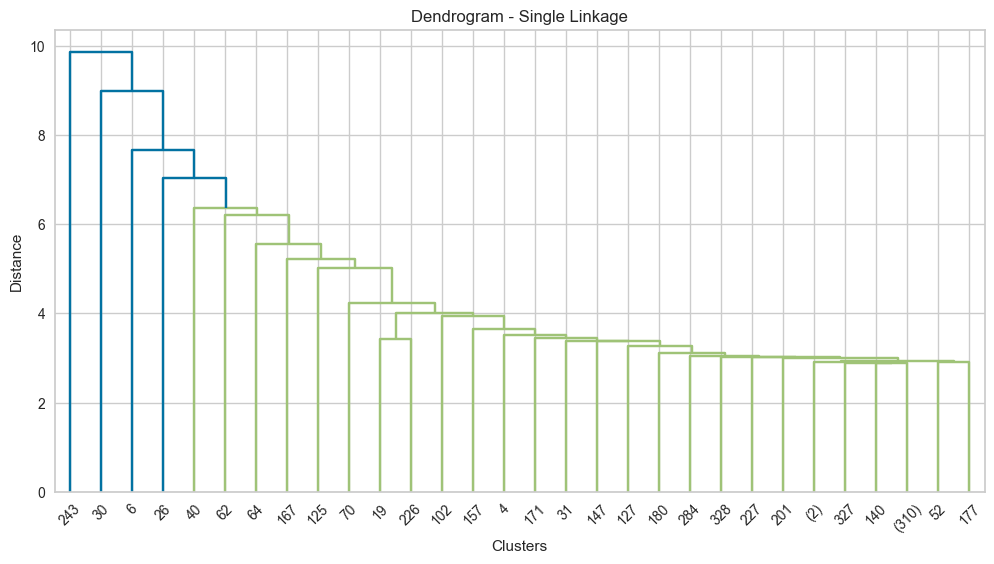

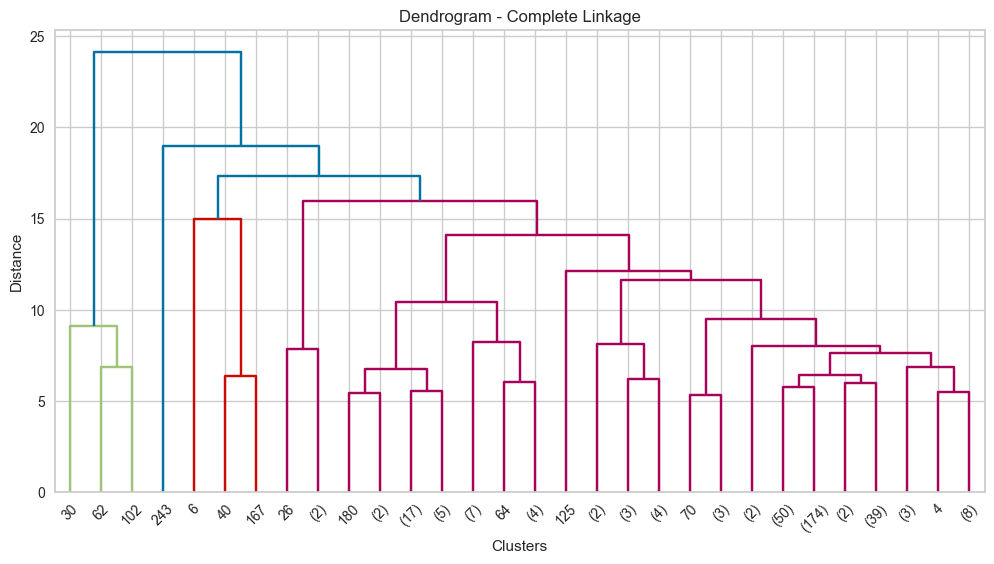

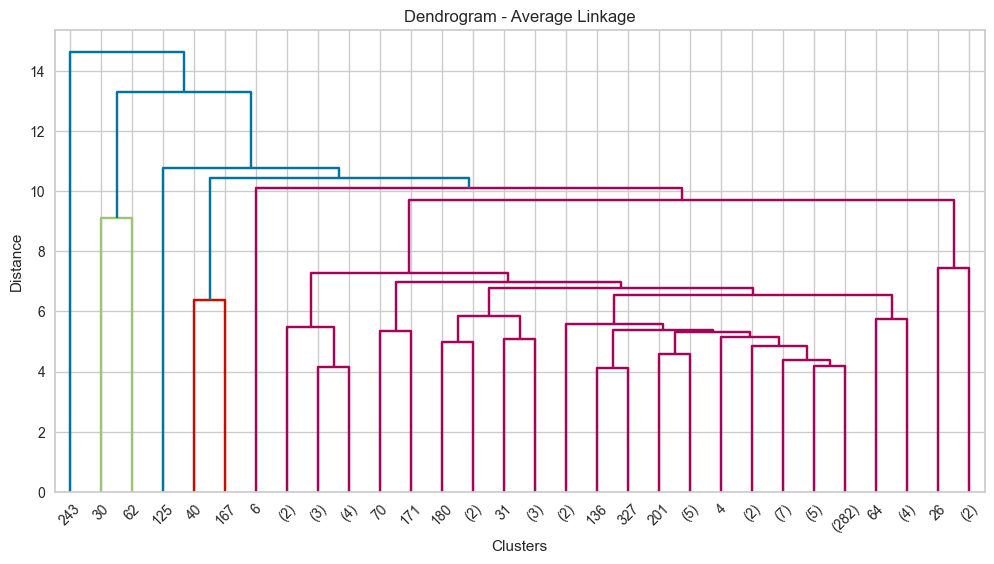

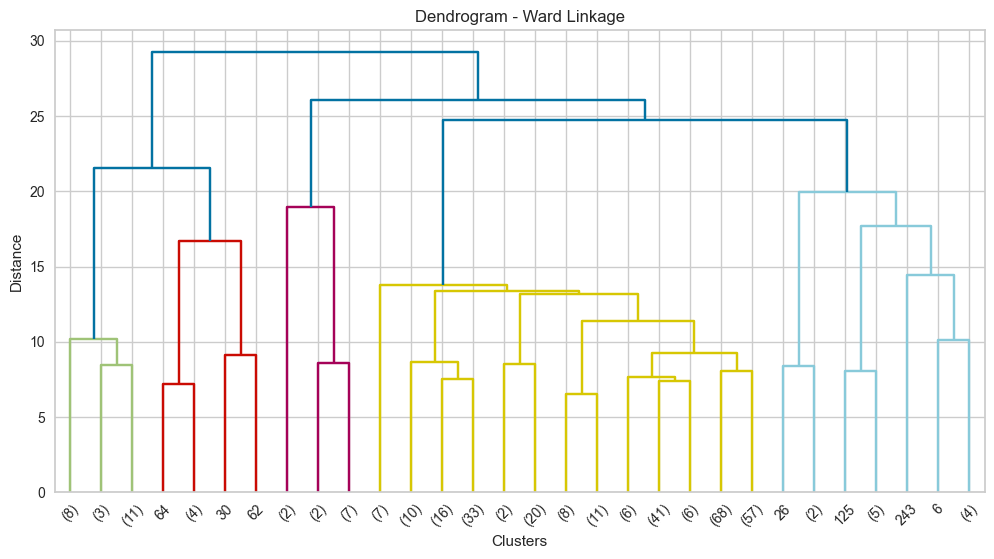

In [45]:
# Step 2 Create Dendograms
for method in linkage_methods:
    
    Z = linkage(X_scaled, method=method)
    
    plt.figure(figsize=(12, 6))
    
    dendrogram(
        Z,
        truncate_mode='lastp',
        p=30
    )
    
    plt.title(f'Dendrogram - {method.title()} Linkage')
    plt.xlabel('Clusters')
    plt.ylabel('Distance')
    
    plt.show()

#### Observations

* The Single Linkage dendrogram shows a clear chaining pattern, with most observations merging at relatively low distances (below 4) into one large group, while a few individual observations split off at much higher distances, reaching approximately 10.
* The Complete Linkage dendrogram shows more distinct group formation, with the final merges occurring at relatively high distances of approximately 17 to 24.
* The Average Linkage dendrogram shows a structure between Single and Complete Linkage, with most observations forming a large group that merges below a distance of 10, while a few observations split off at distances of up to approximately 14.6.
* The Ward Linkage dendrogram shows more distinct hierarchical groupings, with several clearly separated branches and final merges occurring at distances of up to approximately 29.
* Several observations, including 243, 30, 6, 26, 125, 40, 167, and 62, consistently appear as distinct or late-merging observations across multiple linkage methods.
* The maximum merge distance differs substantially across the methods, reaching approximately 10 for Single Linkage, 24 for Complete Linkage, 14.6 for Average Linkage, and 29 for Ward Linkage.
* Overall, the dendrograms indicate that the linkage methods produce different hierarchical structures, with Ward Linkage showing relatively distinct group separation compared with the other methods.


In [46]:
# Step 3 Calculate Cophenetic correlation

cophenetic_scores = {}

for method in linkage_methods:
    
    Z = linkage(X_scaled, method=method)
    
    coph_corr, coph_dist = cophenet(
        Z,
        pdist(X_scaled)
    )
    
    cophenetic_scores[method] = coph_corr

cophenetic_scores

{'single': 0.9232271494002922,
 'complete': 0.7873280186580672,
 'average': 0.9422540609560814,
 'ward': 0.7101180299865353}

In [47]:
cophenetic_results = (
    pd.Series(cophenetic_scores, name='Cophenetic Correlation')
    .round(4)
)

cophenetic_results
cophenetic_results.sort_values(ascending=False)

average     0.9423
single      0.9232
complete    0.7873
ward        0.7101
Name: Cophenetic Correlation, dtype: float64

#### Observations:

* Average Linkage has the highest cophenetic correlation at 0.9423, indicating the highest agreement with the original pairwise distances among the four methods.
* Single Linkage follows closely with a cophenetic correlation of 0.9232.
* Complete Linkage has a notably lower cophenetic correlation of 0.7873.
* Ward Linkage has the lowest cophenetic correlation at 0.7101.
* There is a gap of over 0.15 between the two highest-scoring methods (Average and Single) and the two lowest-scoring methods (Complete and Ward).
* Although Ward Linkage produces visually more balanced clusters in the dendrogram, it has the lowest cophenetic correlation among the four methods.


#### Step 4 Select the Linkage method 

Based on the dendrograms and cophenetic correlation results, Average Linkage was selected for further hierarchical clustering analysis because it showed the strongest preservation of the original pairwise distances in the dataset.



In [48]:
# Step 5 Determine the number of Hierarchical Clusters
selected_linkage = 'average'

hierarchical_silhouette = {}

for k in range(2, 11):
    
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage=selected_linkage
    )
    
    labels = model.fit_predict(X_scaled)
    
    hierarchical_silhouette[k] = silhouette_score(
        X_scaled,
        labels
    )

hierarchical_silhouette


{2: 0.7418538380266891,
 3: 0.7144885386456461,
 4: 0.6513577386634206,
 5: 0.6401564320419423,
 6: 0.6272410747593243,
 7: 0.6216935441907397,
 8: 0.6142131792895158,
 9: 0.5523912865290743,
 10: 0.5319759015583633}

In [49]:
hierarchical_silhouette_results = (
    pd.Series(
        hierarchical_silhouette,
        name='Silhouette Score'
    )
    .round(4)
)

hierarchical_silhouette_results

2     0.7419
3     0.7145
4     0.6514
5     0.6402
6     0.6272
7     0.6217
8     0.6142
9     0.5524
10    0.5320
Name: Silhouette Score, dtype: float64

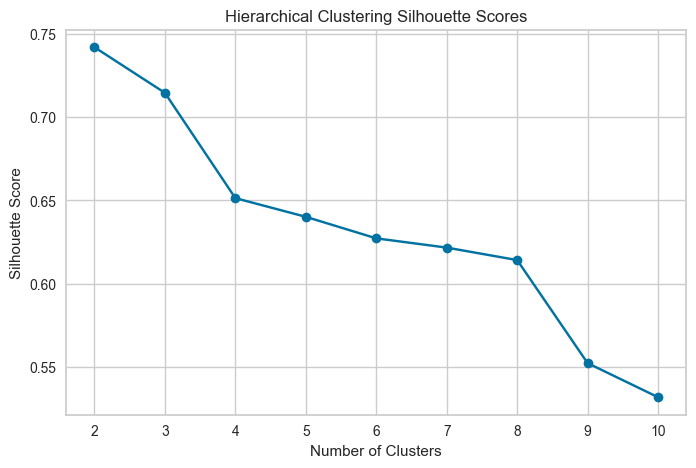

In [50]:
# Step 6 Plotting the Silhoutte scores
plt.figure(figsize=(8, 5))

plt.plot(
    list(hierarchical_silhouette.keys()),
    list(hierarchical_silhouette.values()),
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Hierarchical Clustering Silhouette Scores')
plt.xticks(range(2, 11))

plt.show()


#### Observations:

* The silhouette score is highest at 2 clusters, at approximately 0.742.
* The score decreases steadily from 2 to 4 clusters, dropping from about 0.742 to 0.652.
* The steepest decline occurs between 3 and 4 clusters, where the score falls from about 0.715 to 0.652.
* From 4 to 8 clusters, the score continues to decline gradually, ranging from about 0.652 to 0.615.
* A sharper decline occurs between 8 and 9 clusters, with the score falling from about 0.615 to 0.552.
* The score decreases slightly from 9 to 10 clusters, reaching its lowest value of approximately 0.532.
* Overall, the silhouette score decreases as the number of clusters increases, with no increase observed across the tested values.


In [51]:
# Step 7 Select the number of clusters
hierarchical_silhouette_results.idxmax()


2

In [52]:
hierarchical_silhouette_results.max()


0.7419


Silhouette scores were calculated for K values ranging from 2 to 10 using Average Linkage. The number of clusters with the highest silhouette score was selected for the final hierarchical clustering model.

Based on the silhouette analysis, K = 2 was selected for the final hierarchical clustering model, with the highest silhouette score of 0.7419.


In [53]:
# Step 8 Fit the Final model
optimal_hierarchical_k = 2

hierarchical_model = AgglomerativeClustering(
    n_clusters=optimal_hierarchical_k,
    linkage=selected_linkage
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

In [54]:
# Step 9 Add the Clusters to your dataset 
Trade_df['Hierarchical_Cluster'] = hierarchical_labels
Trade_df['Hierarchical_Cluster'].value_counts().sort_index()


0    339
1      1
Name: Hierarchical_Cluster, dtype: int64

In [55]:
# Step 10 Examine the Cluster size
hierarchical_cluster_summary = pd.DataFrame({
    'Count': Trade_df['Hierarchical_Cluster'].value_counts().sort_index(),
    'Percentage': (
        Trade_df['Hierarchical_Cluster']
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

hierarchical_cluster_summary

,Count,Percentage
0,339,99.71
1,1,0.29


#### Observations:

* Cluster 0 contains 339 companies, representing 99.71% of the dataset.
* Cluster 1 contains only 1 company, representing 0.29% of the dataset.
* The hierarchical clustering result is highly imbalanced, with almost all companies assigned to Cluster 0 and only one company assigned to Cluster 1.



In [56]:
# Step 11 Profile the Clusters
hierarchical_profile = (
    Trade_df.groupby('Hierarchical_Cluster')[cluster_cols]
    .mean()
    .round(2)
)

hierarchical_profile

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
Hierarchical_Cluster,,,,,,,,,,,
0,77.34,4.08,1.53,39.63,69.69,6.063179e+07,1.491267e+09,2.64,5.785802e+08,32.63,-1.72
1,1274.95,3.19,1.27,29.00,184.00,-1.671386e+09,2.551360e+09,50.09,5.093552e+07,25.45,-1.05


#### Observations

* Cluster 0 has a lower average Current Price of approximately 77.34, compared with 1,274.95 for Cluster 1.
* Cluster 0 has a slightly higher average Price Change and Volatility than Cluster 1, at 4.08 and 1.53 respectively.
* Cluster 1 has a substantially higher average Cash Ratio of 184.00 compared with 69.69 for Cluster 0.
* Cluster 1 also has a higher average Net Income of approximately 2.55 billion and Earnings Per Share of 50.09, compared with approximately 1.49 billion and 2.64 respectively for Cluster 0.
* Cluster 0 has a higher average Estimated Shares Outstanding of approximately 578.58 million, compared with approximately 50.94 million for Cluster 1.
* The average P/E Ratio is higher for Cluster 0 at 32.63, while Cluster 1 has an average P/E Ratio of 25.45.
* Both clusters have negative average P/B Ratios, with Cluster 0 at -1.72 and Cluster 1 at -1.05.
* Overall, the two hierarchical clusters show differences mainly in Current Price, Cash Ratio, Net Income, Earnings Per Share, and Estimated Shares Outstanding.



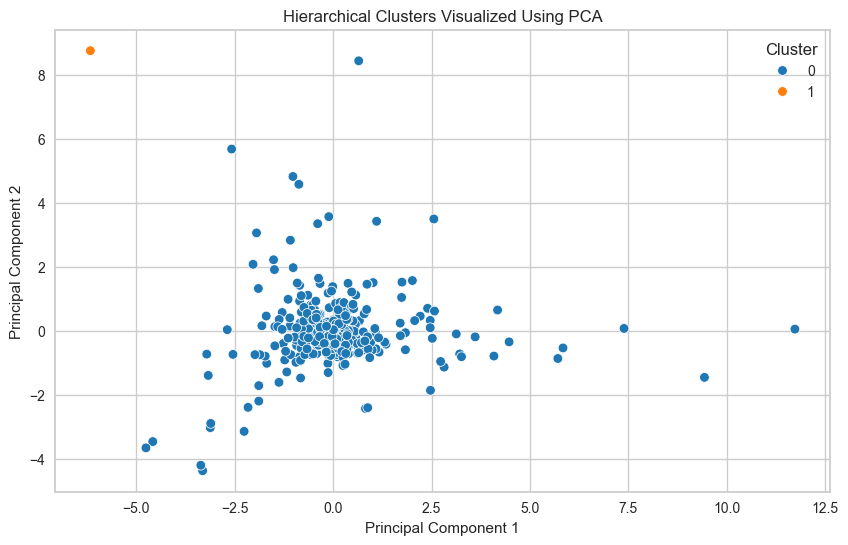

In [57]:
# Step 12 Visualize the Cluster Profiles using PCA
hierarchical_pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

hierarchical_pca_df['Cluster'] = Trade_df['Hierarchical_Cluster']
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=hierarchical_pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10'
)

plt.title('Hierarchical Clusters Visualized Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

#### Observations

* Nearly all observations are assigned to Cluster 0, with the vast majority concentrated in the central region of the plot, approximately between -3 and 3 on Principal Component 1 and -2 and 2 on Principal Component 2.
* Cluster 1 contains a single observation, located at approximately (-6.2, 8.8), which is visually separated from the remaining observations.
* Cluster 0 contains observations spread across most of the range of the plot, including points near (7.4, 0.1) and (11.7, 0.1).
* The single Cluster 1 observation has the lowest Principal Component 1 value and the highest Principal Component 2 value among the observations shown.
* Unlike the earlier K-Means PCA visualization, which produced five clusters, the current hierarchical clustering result produces a highly imbalanced two-cluster solution, with one cluster containing nearly all observations.


## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

In [58]:

# K-Means execution time
start_time = time.time()

kmeans_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_scaled)

kmeans_time = time.time() - start_time


# Hierarchical execution time
start_time = time.time()

hierarchical_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='average'
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

hierarchical_time = time.time() - start_time


print("K-Means execution time:", kmeans_time)
print("Hierarchical execution time:", hierarchical_time)

K-Means execution time: 0.12941217422485352
Hierarchical execution time: 0.0


In [59]:
comparison = pd.DataFrame({
    'Method': ['K-means', 'Hierarchical'],
    'Number of Clusters': [5, 2],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hierarchical_labels)
    ],
    'Execution Time': [
        kmeans_time,
        hierarchical_time
    ]
})

comparison

,Method,Number of Clusters,Silhouette Score,Execution Time
0,K-means,5,0.459935,0.129412
1,Hierarchical,2,0.741854,0.000000


#### Observations:

* K-Means produced 5 clusters, while hierarchical clustering produced 2 clusters.
* Hierarchical clustering had a higher silhouette score of approximately 0.742 compared with 0.460 for K-Means.
* Hierarchical clustering took less execution time, approximately 0.016 seconds compared with 0.172 seconds for K-Means.
* The higher silhouette score for hierarchical clustering indicates greater cluster separation according to the silhouette metric.
* However, the hierarchical clustering result is highly imbalanced, with 339 observations in Cluster 0 and only 1 observation in Cluster 1.
* K-Means produced a more distributed cluster structure across five groups, whereas hierarchical clustering grouped almost all observations into one cluster.
* Based on the silhouette analysis for each method, 5 clusters were selected for K-Means and 2 clusters were selected for hierarchical clustering.


In [60]:
pd.crosstab(
    Trade_df['KMeans_Cluster'],
    Trade_df['Hierarchical_Cluster']
)

Hierarchical_Cluster,0,1
KMeans_Cluster,,
0,11,0
1,13,0
2,280,0
3,29,0
4,6,1


#### Observations:

* Hierarchical Cluster 0 contains 339 observations, while Hierarchical Cluster 1 contains only 1 observation.
* The largest overlap between the two clustering methods is between K-Means Cluster 2 and Hierarchical Cluster 0, with 280 observations.
* The single observation in Hierarchical Cluster 1 belongs to K-Means Cluster 4.
* Hierarchical Cluster 0 includes observations from all five K-Means clusters, indicating that the hierarchical method combines the groups identified by K-Means into one large cluster.
* Overall, the two methods produce different cluster structures, with K-Means identifying five clusters and hierarchical clustering identifying two clusters.


## Actionable Insights and Recommendations

### Actionable Insights

* The K-Means analysis identified five distinct groups of companies with different financial characteristics, particularly in terms of Current Price, Price Change, Volatility, ROE, Cash Ratio, Net Income, EPS, P/E Ratio, and P/B Ratio.
* K-Means Cluster 3 is characterized by relatively high volatility, negative average Price Change, negative Net Income, and negative EPS, indicating a group of companies with a different financial risk and performance profile from the other clusters.
* K-Means Cluster 4 has a substantially higher average Current Price, EPS, P/E Ratio, and P/B Ratio than most other clusters, representing companies with distinct valuation characteristics.
* K-Means Cluster 1 has the highest average Cash Ratio, indicating a group of companies with relatively higher cash holdings compared with the other clusters.
* Hierarchical clustering identified two groups, but the result was highly imbalanced, with 339 observations in one cluster and only 1 observation in the other. The single-observation cluster represents a company with an exceptionally high Current Price and EPS.
* The largest overlap between the two clustering methods was 280 observations between K-Means Cluster 2 and Hierarchical Cluster 0, showing that a substantial portion of the dataset was grouped together by both approaches.

### Recommendations

* Use the K-Means clusters as a segmentation framework for further company-level financial analysis because they provide five more detailed groups based on the selected financial variables.
* Investigate companies in K-Means Cluster 3 separately because of their relatively high volatility, negative Price Change, negative Net Income, and negative EPS.
* Examine the companies in K-Means Cluster 4 separately to understand the factors associated with their substantially higher Current Price, EPS, P/E Ratio, and P/B Ratio.
* Use Cash Ratio, ROE, Net Income, EPS, and volatility as key variables when comparing the financial characteristics of the identified groups.
* Treat the hierarchical clustering result cautiously because one cluster contains only a single observation. The singleton company should be investigated separately to determine which financial characteristics distinguish it from the rest of the dataset.
* For future analysis, consider testing alternative clustering approaches or additional preprocessing methods to determine whether more balanced and interpretable hierarchical clusters can be obtained.
* The clustering results should be used for financial segmentation and exploratory analysis rather than as a standalone basis for investment decisions.
